<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8009/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - Loan Prediction Dataset

## Objetivo
Realizar un análisis exploratorio de datos (EDA) completo sobre un dataset de solicitudes de préstamos para identificar patrones, tendencias y preparar los datos para modelado predictivo.

## Dataset
El dataset contiene información sobre solicitudes de préstamos con las siguientes variables:

| Variable | Descripción | Tipo |
|----------|-------------|------|
| Loan_ID | Identificador único del préstamo | Categórica |
| Gender | Género del solicitante (Male/Female) | Categórica |
| Married | Estado civil (Yes/No) | Categórica |
| Dependents | Número de dependientes (0, 1, 2, 3+) | Categórica |
| Education | Nivel educativo (Graduate/Not Graduate) | Categórica |
| Self_Employed | Trabajador independiente (Yes/No) | Categórica |
| ApplicantIncome | Ingreso del solicitante | Numérica |
| CoapplicantIncome | Ingreso del co-solicitante | Numérica |
| LoanAmount | Monto del préstamo (en miles) | Numérica |
| Loan_Amount_Term | Plazo del préstamo (en meses) | Numérica |
| Credit_History | Historial crediticio (1=bueno, 0=malo) | Categórica |
| Property_Area | Área de la propiedad (Urban/Semiurban/Rural) | Categórica |
| Loan_Status | Estado del préstamo - Variable objetivo (Y=Aprobado, N=Rechazado) | Categórica |

## Estructura del EDA
1. Carga y configuración inicial
2. Exploración inicial de datos
3. Análisis de calidad de datos
4. Análisis univariado
5. Análisis bivariado
6. Tratamiento de datos
7. Análisis con Spark SQL

---

## 1. Carga y Configuración Inicial

Importamos las librerías necesarias y configuramos el entorno de trabajo.

In [ ]:
# =============================================================================
# LIBRERÍAS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización (estilo de gráficos y paleta de colores)
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [ ]:
# =============================================================================
# CARGA DE DATOS DESDE DATABRICKS
# =============================================================================

# Leer el dataset usando Spark (Databricks)
train_spark = spark.table("default.train")

# Convertir a Pandas DataFrame para análisis exploratorio
df = train_spark.toPandas()

## 2. Exploración Inicial de Datos

Conocer la estructura básica del dataset: dimensiones, tipos de datos y primeros registros.

In [ ]:
# =============================================================================
# VISTA PREVIA DE LOS DATOS
# =============================================================================

print("=" * 60)
print("PRIMEROS 10 REGISTROS")
print("=" * 60)
df.head(10)

PRIMEROS 10 REGISTROS


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
6,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
7,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
8,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
9,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N


In [ ]:
# =============================================================================
# INFORMACIÓN GENERAL DEL DATASET
# =============================================================================

print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print("\n" + "=" * 60)
print("TIPOS DE DATOS")
print("=" * 60)
df.info()

INFORMACIÓN DEL DATASET

Dimensiones: 621 filas x 13 columnas

Columnas: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            621 non-null    object 
 1   Gender             608 non-null    object 
 2   Married            618 non-null    object 
 3   Dependents         606 non-null    object 
 4   Education          621 non-null    object 
 5   Self_Employed      589 non-null    object 
 6   ApplicantIncome    621 non-null    int64  
 7   CoapplicantIncome  621 non-null    float64
 8   LoanAmount         599 non-null    float64
 9   Loan_Amount_Term   607 non-null    float64
 10  Credit_History     571 n

In [ ]:
# =============================================================================
# CLASIFICACIÓN DE VARIABLES
# =============================================================================

# Identificar variables numéricas y categóricas
vars_numericas = df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
vars_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("=" * 60)
print("CLASIFICACIÓN DE VARIABLES")
print("=" * 60)
print(f"\nVariables Numéricas ({len(vars_numericas)}):")
for var in vars_numericas:
    print(f"  - {var}")

print(f"\nVariables Categóricas ({len(vars_categoricas)}):")
for var in vars_categoricas:
    print(f"  - {var}")

CLASIFICACIÓN DE VARIABLES

Variables Numéricas (5):
  - ApplicantIncome
  - CoapplicantIncome
  - LoanAmount
  - Loan_Amount_Term
  - Credit_History

Variables Categóricas (8):
  - Loan_ID
  - Gender
  - Married
  - Dependents
  - Education
  - Self_Employed
  - Property_Area
  - Loan_Status


## 3. Análisis de Calidad de Datos

Identificar problemas de calidad: duplicados, valores faltantes y valores únicos.

In [ ]:
# =============================================================================
# DETECCIÓN DE DUPLICADOS
# =============================================================================

print("=" * 60)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 60)

# Duplicados por Loan_ID (identificador único)
duplicados_id = df[df.duplicated(subset='Loan_ID', keep=False)]
print(f"\nRegistros con Loan_ID duplicado: {len(duplicados_id)}")

# Duplicados completos (todas las columnas)
duplicados_total = df[df.duplicated(keep=False)]
print(f"Registros completamente duplicados: {len(duplicados_total)}")

if len(duplicados_id) > 0:
    print("\nRegistros duplicados encontrados:")
    display(duplicados_id.sort_values('Loan_ID'))

ANÁLISIS DE DUPLICADOS

Registros con Loan_ID duplicado: 14
Registros completamente duplicados: 14

Registros duplicados encontrados:


Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
LP001032,Male,No,0,Graduate,No,4950,0.0,125.0,360.0,1.0,Urban,Y
LP001032,Male,No,0,Graduate,No,4950,0.0,125.0,360.0,1.0,Urban,Y
LP001047,Male,Yes,0,Not Graduate,No,2600,1911.0,116.0,360.0,0.0,Semiurban,N
LP001047,Male,Yes,0,Not Graduate,No,2600,1911.0,116.0,360.0,0.0,Semiurban,N
LP001846,Female,No,3+,Graduate,No,3083,0.0,255.0,360.0,1.0,Rural,Y
LP001846,Female,No,3+,Graduate,No,3083,0.0,255.0,360.0,1.0,Rural,Y


In [ ]:
# =============================================================================
# ELIMINAR DUPLICADOS
# =============================================================================

print("Eliminando duplicados...")
df_original_shape = df.shape[0]

# Eliminar duplicados y resetear índice
df = df.drop_duplicates().reset_index(drop=True)

print(f"\nRegistros antes: {df_original_shape}")
print(f"Registros después: {df.shape[0]}")
print(f"Registros eliminados: {df_original_shape - df.shape[0]}")

display(df.sort_values('Loan_ID'))

Eliminando duplicados...

Registros antes: 621
Registros después: 614
Registros eliminados: 7


Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
LP001002,Male,No,0,Graduate,No,5849,0.0,null,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


Databricks data profile. Run in Databricks to view.

In [ ]:
# =============================================================================
# ANÁLISIS DE VALORES FALTANTES
# =============================================================================

def analizar_valores_faltantes(dataframe):
    """
    Genera una tabla resumen de valores faltantes por columna.
    """
    faltantes = dataframe.isnull().sum()
    porcentaje = (faltantes / len(dataframe)) * 100

    tabla = pd.DataFrame({
        'Columna': faltantes.index,
        'Valores Faltantes': faltantes.values,
        'Porcentaje (%)': porcentaje.values.round(2)
    })

    return tabla.sort_values('Porcentaje (%)', ascending=False).reset_index(drop=True)

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

tabla_faltantes = analizar_valores_faltantes(df)
display(tabla_faltantes)

# Resumen
total_faltantes = df.isnull().sum().sum()
total_celdas = df.shape[0] * df.shape[1]
print(f"\nTotal de valores faltantes: {total_faltantes} de {total_celdas} ({(total_faltantes/total_celdas*100):.2f}%)")

ANÁLISIS DE VALORES FALTANTES


Columna,Valores Faltantes,Porcentaje (%)
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49
Loan_ID,0,0.0
Education,0,0.0
ApplicantIncome,0,0.0



Total de valores faltantes: 149 de 7982 (1.87%)


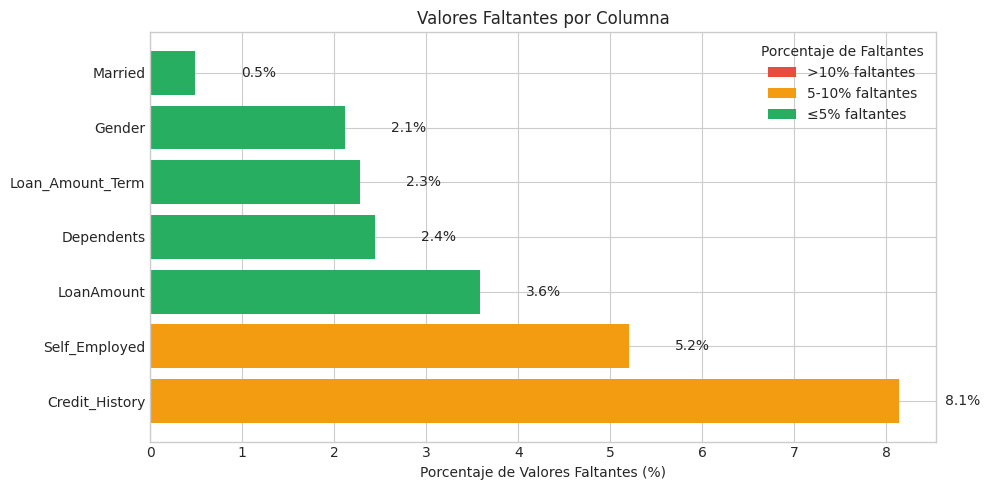

In [ ]:
# =============================================================================
# VISUALIZACIÓN DE VALORES FALTANTES
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Solo columnas con valores faltantes
cols_con_faltantes = tabla_faltantes[tabla_faltantes['Valores Faltantes'] > 0]

if len(cols_con_faltantes) > 0:
    colors = ['#e74c3c' if x > 10 else '#f39c12' if x > 5 else '#27ae60'
              for x in cols_con_faltantes['Porcentaje (%)']]

    bars = ax.barh(cols_con_faltantes['Columna'],
                   cols_con_faltantes['Porcentaje (%)'],
                   color=colors)

    ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
    ax.set_title('Valores Faltantes por Columna')

    # Añadir etiquetas de valor
    for bar, val in zip(bars, cols_con_faltantes['Porcentaje (%)']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center')

    # Añadir leyenda de colores
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='>10% faltantes'),
        Patch(facecolor='#f39c12', label='5-10% faltantes'),
        Patch(facecolor='#27ae60', label='≤5% faltantes')
    ]
    ax.legend(handles=legend_elements, title='Porcentaje de Faltantes')

    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes en el dataset.")

## 4. Análisis Univariado

Analizar cada variable individualmente: distribución, estadísticas descriptivas y valores únicos.

In [ ]:
# =============================================================================
# ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
# =============================================================================

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 60)

df[vars_numericas].describe().round(2)

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,592.00,600.00,564.00
mean,5403.46,1621.25,146.41,342.00,0.84
std,6109.04,2926.25,85.59,65.12,0.36
min,150.00,0.00,9.00,12.00,0.00
25%,2877.50,0.00,100.00,360.00,1.00
50%,3812.50,1188.50,128.00,360.00,1.00
75%,5795.00,2297.25,168.00,360.00,1.00
max,81000.00,41667.00,700.00,480.00,1.00


In [ ]:
# =============================================================================
# ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS
# =============================================================================

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("=" * 60)

df[vars_categoricas].describe()

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
# =============================================================================
# DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# =============================================================================

print("=" * 60)
print("DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Excluir Loan_ID (es un identificador)
vars_cat_analisis = [col for col in vars_categoricas if col != 'Loan_ID']

for col in vars_cat_analisis:
    print(f"\n--- {col} ---")
    tabla = pd.crosstab(index=df[col], columns='Frecuencia')
    tabla['Porcentaje (%)'] = (tabla['Frecuencia'] / tabla['Frecuencia'].sum() * 100).round(2)
    display(tabla)

DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS

--- Gender ---


Frecuencia,Porcentaje (%)
112,18.64
489,81.36



--- Married ---


Frecuencia,Porcentaje (%)
213,34.86
398,65.14



--- Dependents ---


...

Frecuencia,Porcentaje (%)
500,85.91
82,14.09



--- Property_Area ---


Frecuencia,Porcentaje (%)
179,29.15
233,37.95
202,32.9



--- Loan_Status ---


Frecuencia,Porcentaje (%)
192,31.27
422,68.73


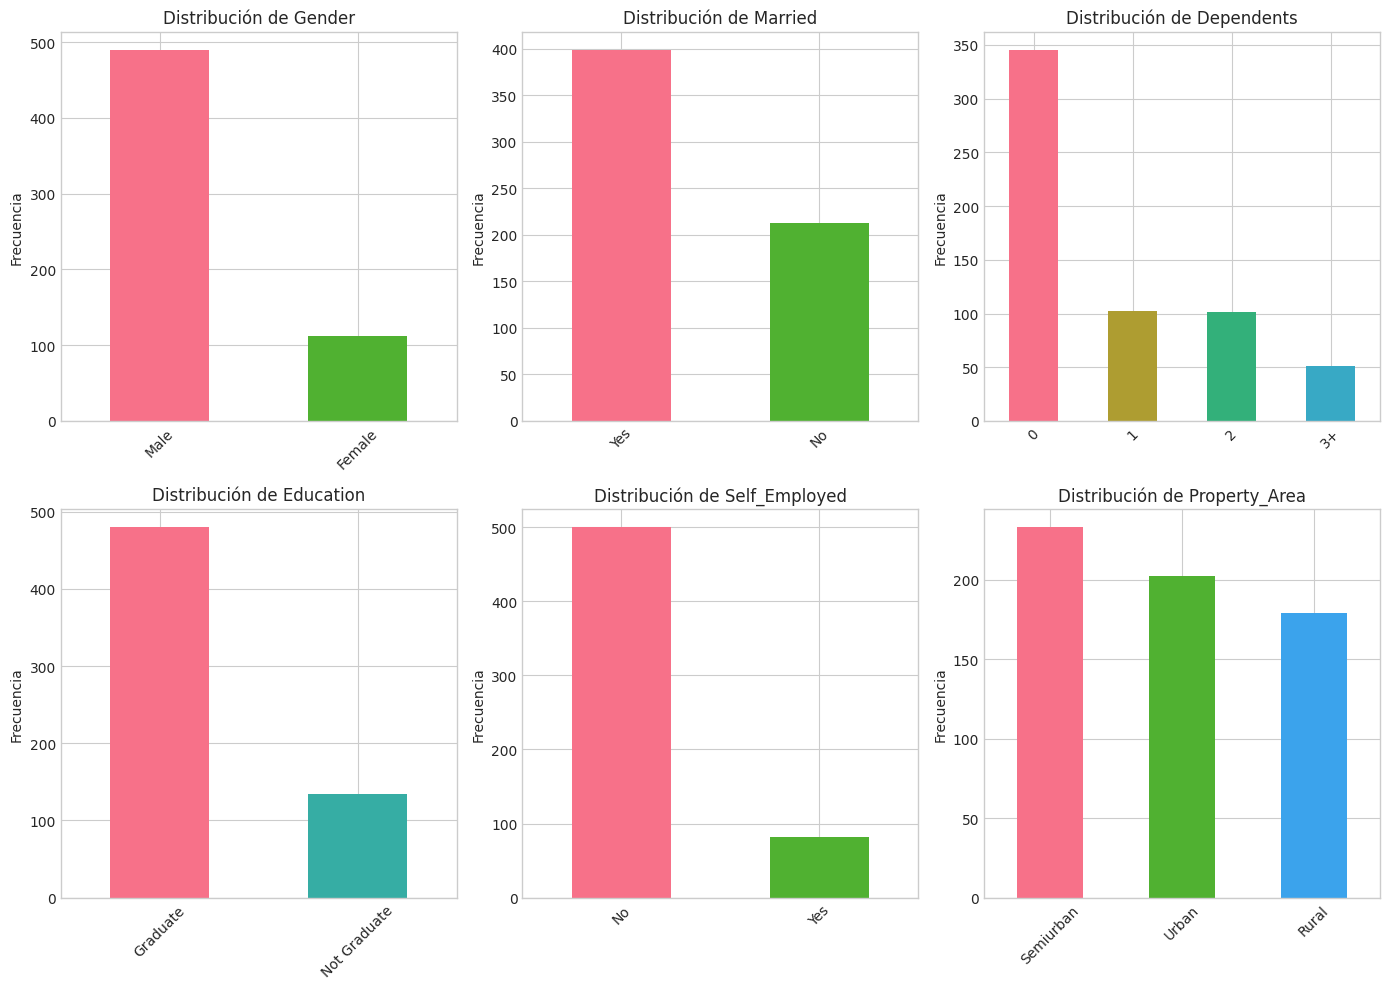

In [ ]:
# =============================================================================
# VISUALIZACIÓN - DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars_cat_analisis[:6]):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color=sns.color_palette('husl', len(df[col].unique())))
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

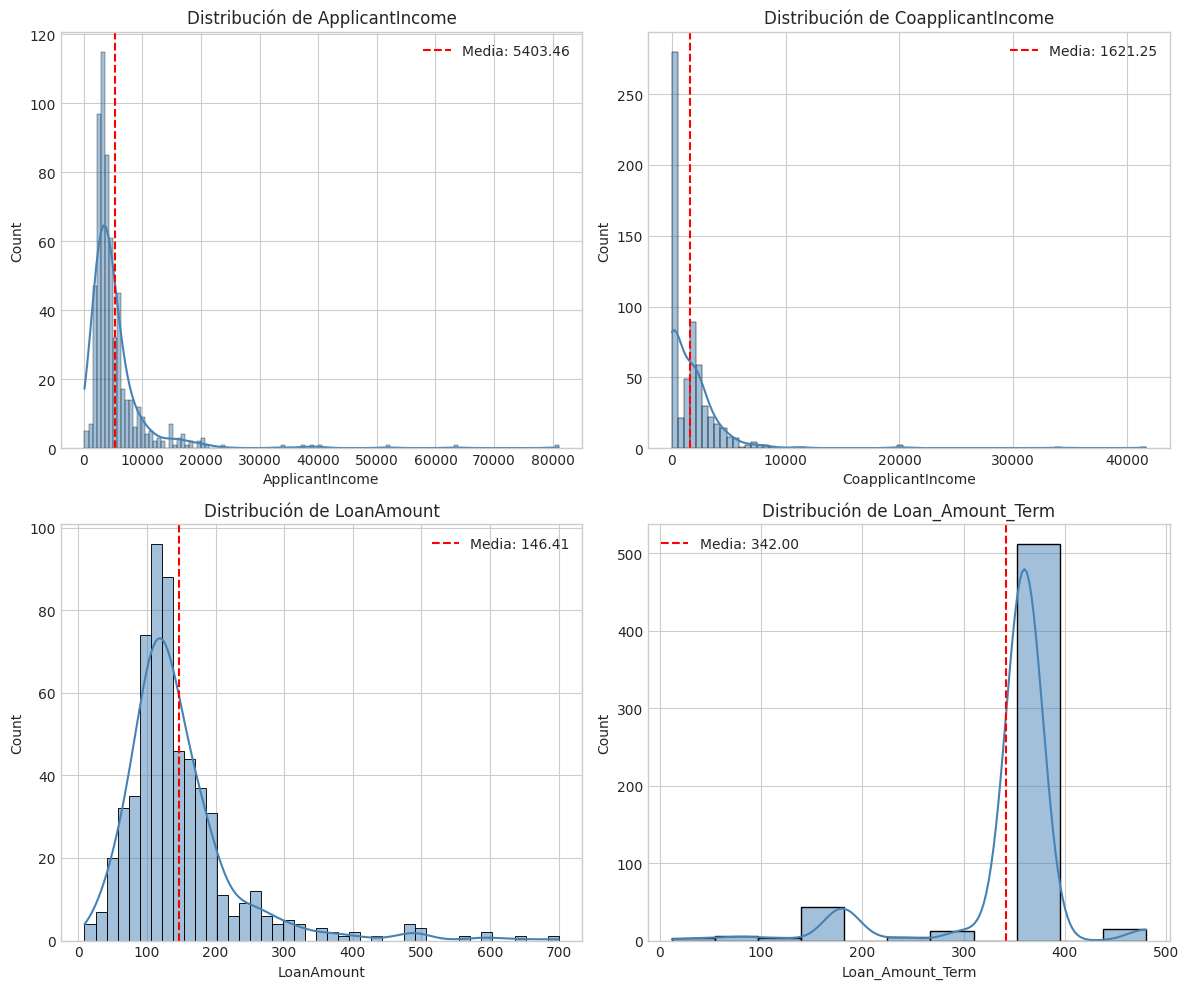

In [ ]:
# =============================================================================
# VISUALIZACIÓN - DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

vars_num_analisis = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

for i, col in enumerate(vars_num_analisis):
    # Histograma con curva de densidad
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)

    # Añadir línea de media
    media = df[col].mean()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

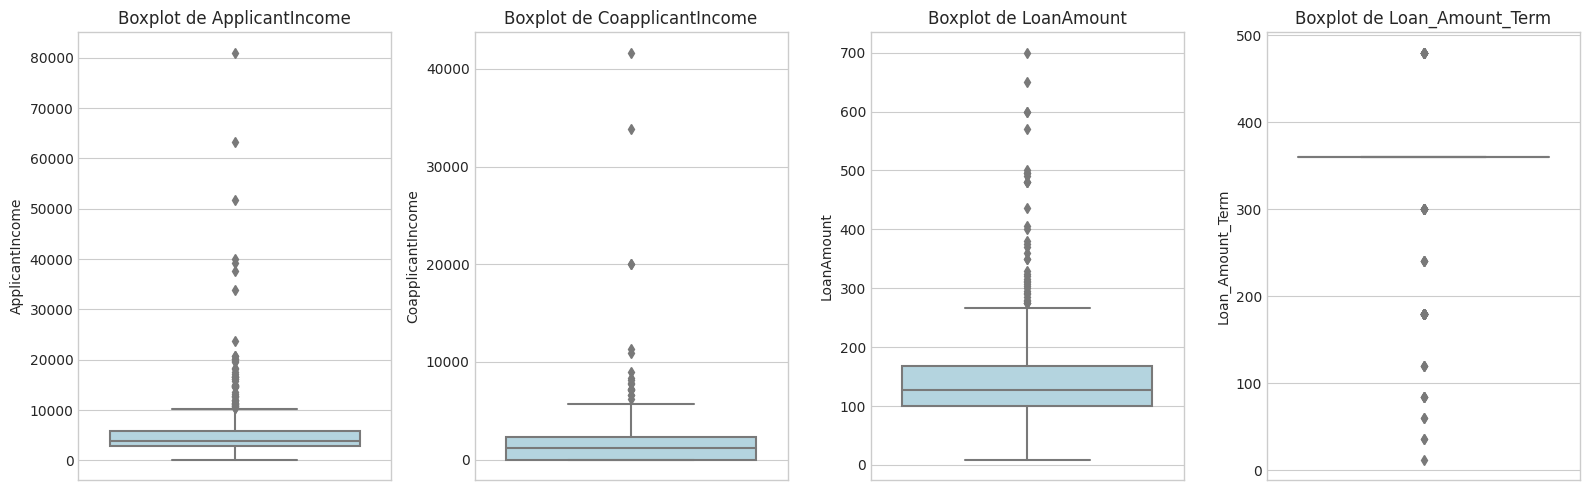

In [ ]:
# =============================================================================
# ANÁLISIS DE OUTLIERS - BOXPLOTS
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(vars_num_analisis):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# DETECCIÓN DE OUTLIERS USANDO IQR
# =============================================================================

def detectar_outliers_iqr(dataframe, columna):
    """
    Detecta outliers usando el método del rango intercuartílico (IQR).
    Outlier: valor < Q1 - 1.5*IQR o valor > Q3 + 1.5*IQR
    """
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[columna] < limite_inferior) |
                         (dataframe[columna] > limite_superior)][columna]

    return {
        'columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': outliers.count(),
        'porcentaje': round(outliers.count() / dataframe[columna].count() * 100, 2)
    }

print("=" * 60)
print("ANÁLISIS DE OUTLIERS (Método IQR)")
print("=" * 60)

resultados_outliers = []
for col in vars_num_analisis:
    resultado = detectar_outliers_iqr(df, col)
    resultados_outliers.append(resultado)
    print(f"\n{col}:")
    print(f"  Rango válido: [{resultado['limite_inferior']:.2f}, {resultado['limite_superior']:.2f}]")
    print(f"  Outliers encontrados: {resultado['n_outliers']} ({resultado['porcentaje']}%)")

ANÁLISIS DE OUTLIERS (Método IQR)

ApplicantIncome:
  Rango válido: [-1498.75, 10171.25]
  Outliers encontrados: 50 (8.14%)

CoapplicantIncome:
  Rango válido: [-3445.88, 5743.12]
  Outliers encontrados: 18 (2.93%)

LoanAmount:
  Rango válido: [-2.00, 270.00]
  Outliers encontrados: 39 (6.59%)

Loan_Amount_Term:
  Rango válido: [360.00, 360.00]
  Outliers encontrados: 88 (14.67%)


## 5. Análisis Multivariado

Analizar relaciones entre variables: correlaciones, cruces y visualizaciones comparativas.

MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS


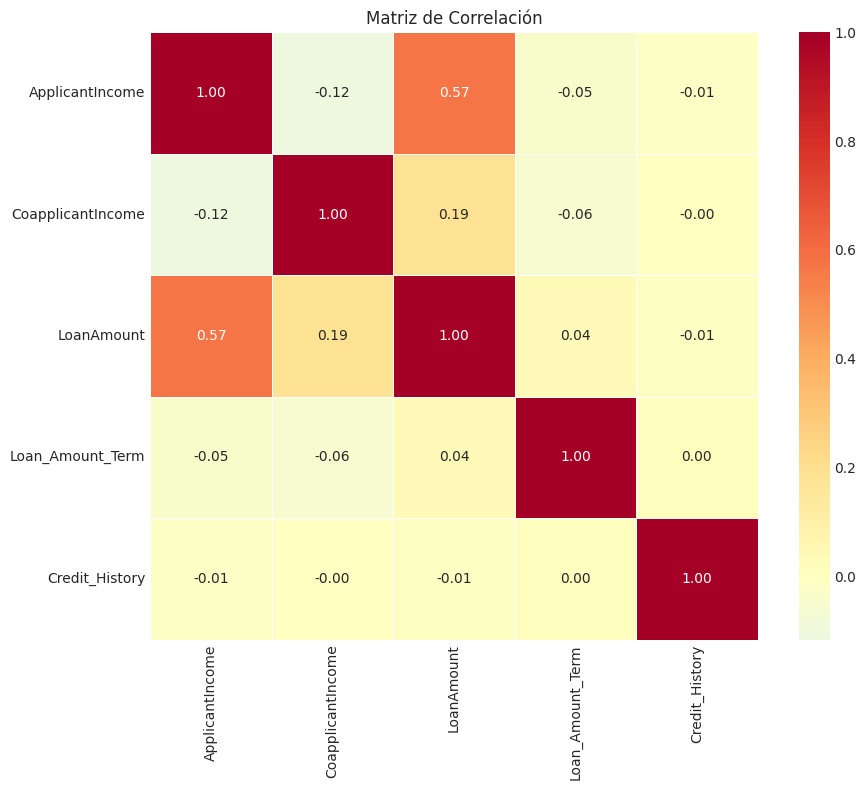

In [ ]:
# =============================================================================
# MATRIZ DE CORRELACIÓN
# =============================================================================

print("=" * 60)
print("MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS")
print("=" * 60)

# Calcular correlación
correlacion = df[vars_numericas].corr()

# Visualizar con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


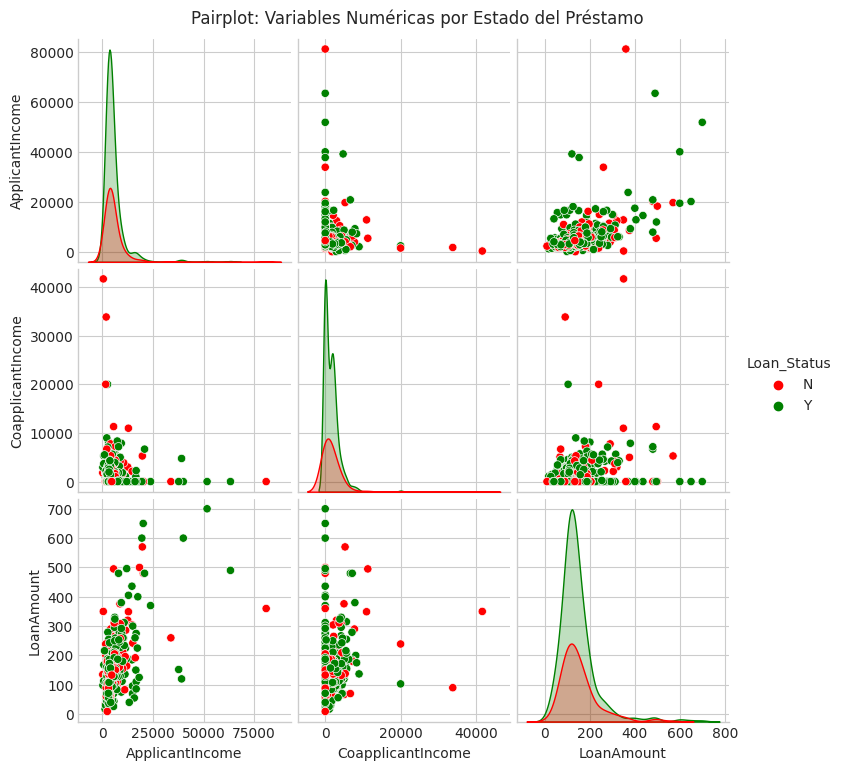

In [ ]:
# =============================================================================
# PAIRPLOT - RELACIONES ENTRE VARIABLES NUMÉRICAS
# =============================================================================

# Seleccionar variables para el pairplot (evitar demasiadas)
vars_pairplot = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Status']

# Crear copia temporal para el gráfico
df_temp = df[vars_pairplot].dropna().copy()

sns.pairplot(df_temp, hue='Loan_Status', palette={'Y': 'green', 'N': 'red'},
             diag_kind='kde', height=2.5)
plt.suptitle('Pairplot: Variables Numéricas por Estado del Préstamo', y=1.02)
plt.show()

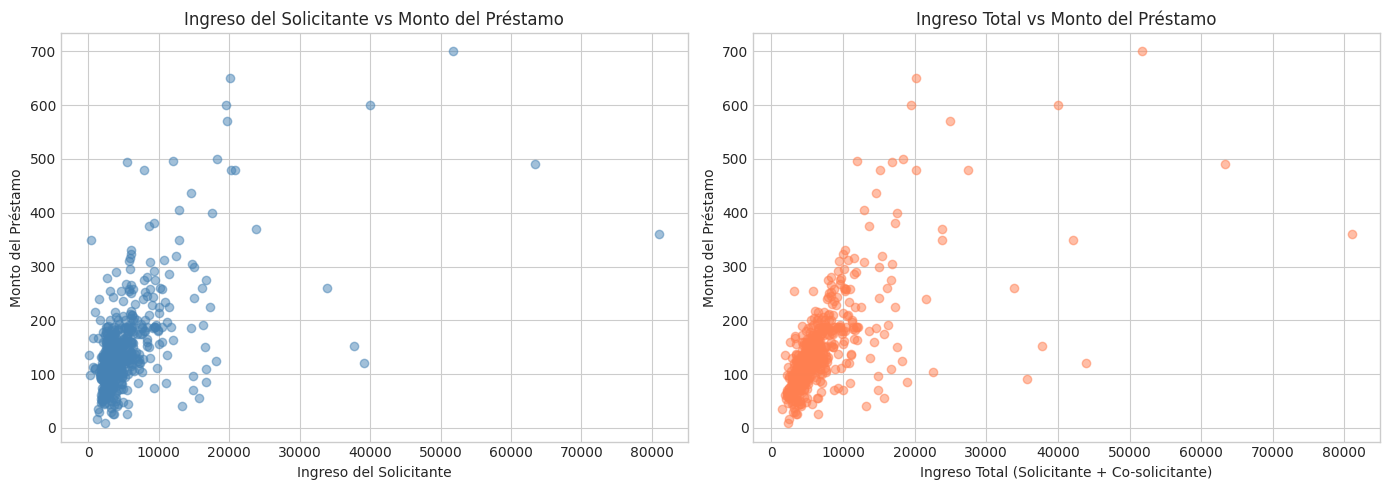

In [ ]:
# =============================================================================
# DIAGRAMA DE DISPERSIÓN: INGRESO VS MONTO DEL PRÉSTAMO
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ingreso del solicitante vs Monto del préstamo
axes[0].scatter(df['ApplicantIncome'], df['LoanAmount'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('Ingreso del Solicitante')
axes[0].set_ylabel('Monto del Préstamo')
axes[0].set_title('Ingreso del Solicitante vs Monto del Préstamo')

# Ingreso total vs Monto del préstamo
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
axes[1].scatter(df['TotalIncome'], df['LoanAmount'], alpha=0.5, c='coral')
axes[1].set_xlabel('Ingreso Total (Solicitante + Co-solicitante)')
axes[1].set_ylabel('Monto del Préstamo')
axes[1].set_title('Ingreso Total vs Monto del Préstamo')

plt.tight_layout()
plt.show()

ANÁLISIS DE LA VARIABLE OBJETIVO: Loan_Status


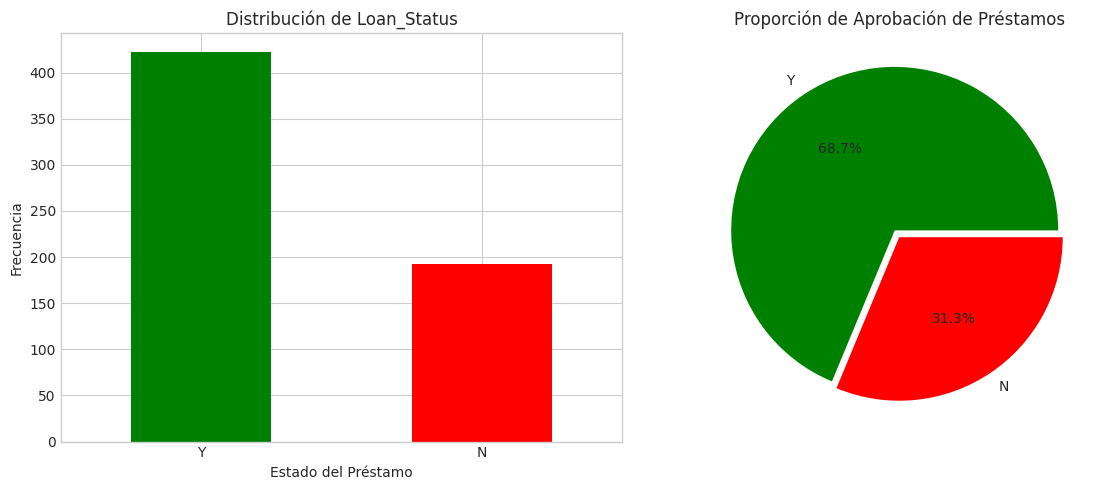


Tabla de frecuencias:


Frecuencia,Porcentaje (%)
192,31.27
422,68.73


In [ ]:
# =============================================================================
# ANÁLISIS: VARIABLE OBJETIVO (Loan_Status)
# =============================================================================

print("=" * 60)
print("ANÁLISIS DE LA VARIABLE OBJETIVO: Loan_Status")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribución de Loan_Status
df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0],
                                       color=['green', 'red'])
axes[0].set_title('Distribución de Loan_Status')
axes[0].set_xlabel('Estado del Préstamo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Loan_Status'].value_counts().plot(kind='pie', ax=axes[1],
                                       autopct='%1.1f%%',
                                       colors=['green', 'red'],
                                       explode=[0.05, 0])
axes[1].set_title('Proporción de Aprobación de Préstamos')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Tabla de frecuencias
print("\nTabla de frecuencias:")
tabla_objetivo = pd.crosstab(index=df['Loan_Status'], columns='Frecuencia')
tabla_objetivo['Porcentaje (%)'] = (tabla_objetivo['Frecuencia'] / tabla_objetivo['Frecuencia'].sum() * 100).round(2)
display(tabla_objetivo)

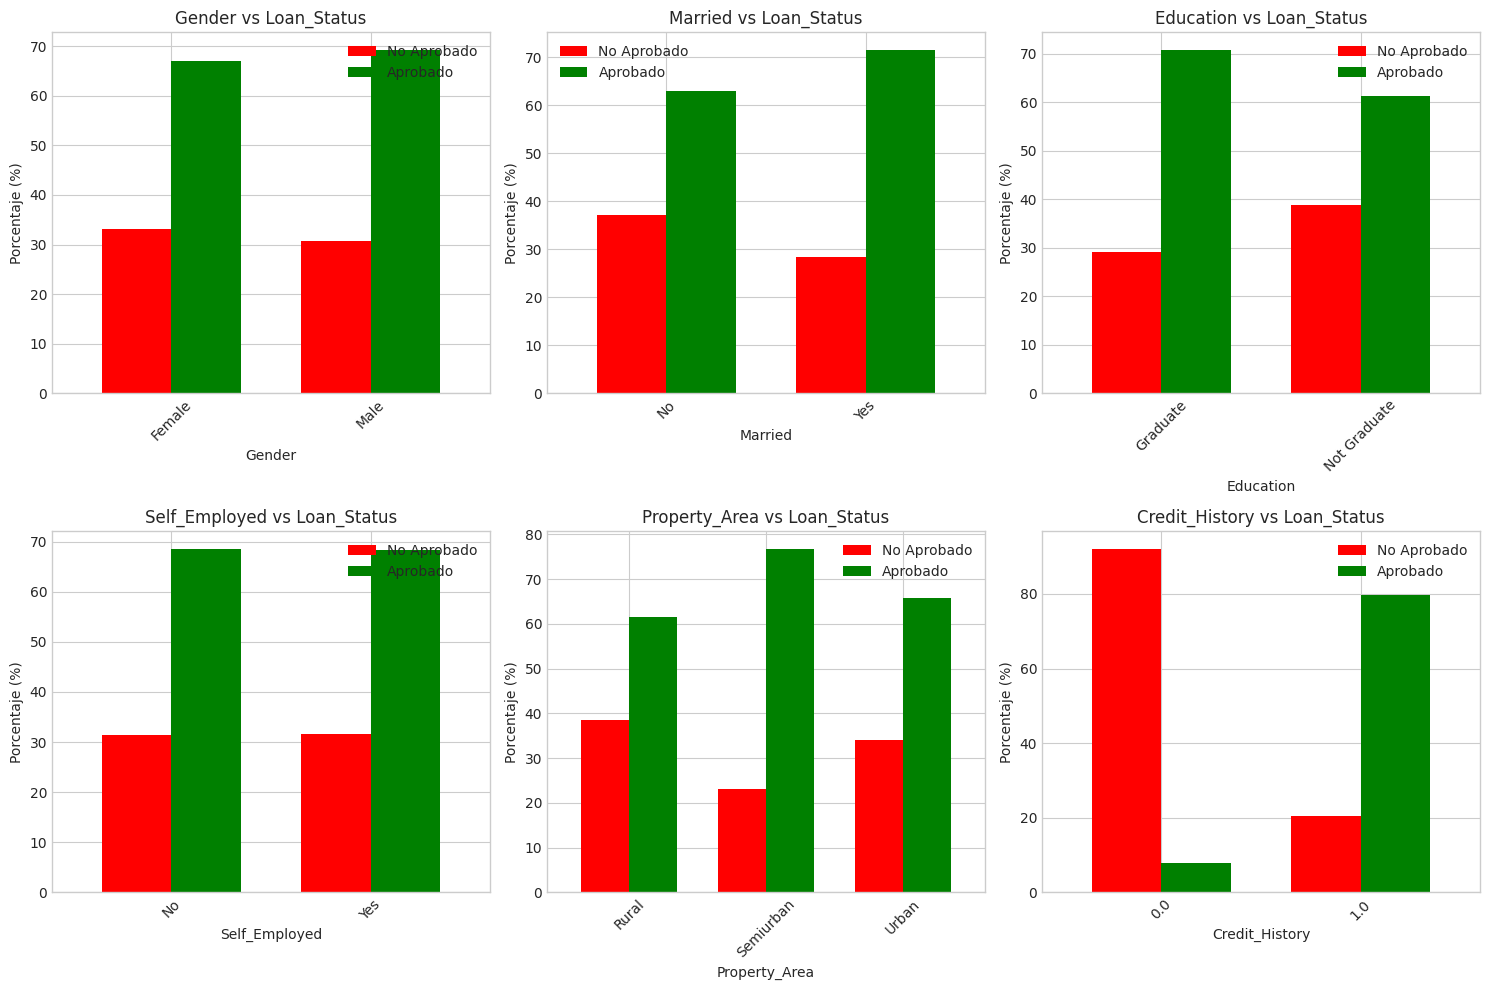

In [ ]:
# =============================================================================
# RELACIÓN: VARIABLES CATEGÓRICAS VS LOAN_STATUS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

vars_analizar = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

for i, col in enumerate(vars_analizar):
    # Crear tabla cruzada normalizada
    ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['red', 'green'], width=0.7)
    axes[i].set_title(f'{col} vs Loan_Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].legend(['No Aprobado', 'Aprobado'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Tratamiento de Datos

Imputación de valores faltantes y codificación de variables categóricas.

In [ ]:
# =============================================================================
# IMPUTACIÓN DE VALORES FALTANTES
# =============================================================================

print("=" * 60)
print("IMPUTACIÓN DE VALORES FALTANTES")
print("=" * 60)

# Crear copia para tratamiento
df_tratado = df.copy()

# Variables categóricas: imputar con la MODA
vars_cat_imputar = ['Gender', 'Married', 'Self_Employed', 'Credit_History', 'Dependents']

print("\nImputación de variables categóricas (usando MODA):")
for col in vars_cat_imputar:
    moda = df_tratado[col].mode()[0]
    n_faltantes = df_tratado[col].isnull().sum()
    df_tratado[col] = df_tratado[col].fillna(moda)
    print(f"  {col}: {n_faltantes} valores imputados con '{moda}'")

# Variables numéricas: imputar con la MEDIANA
vars_num_imputar = ['LoanAmount', 'Loan_Amount_Term']

print("\nImputación de variables numéricas (usando MEDIANA):")
for col in vars_num_imputar:
    mediana = df_tratado[col].median()
    n_faltantes = df_tratado[col].isnull().sum()
    df_tratado[col] = df_tratado[col].fillna(mediana)
    print(f"  {col}: {n_faltantes} valores imputados con {mediana}")

IMPUTACIÓN DE VALORES FALTANTES

Imputación de variables categóricas (usando MODA):
  Gender: 13 valores imputados con 'Male'
  Married: 3 valores imputados con 'Yes'
  Self_Employed: 32 valores imputados con 'No'
  Credit_History: 50 valores imputados con '1.0'
  Dependents: 15 valores imputados con '0'

Imputación de variables numéricas (usando MEDIANA):
  LoanAmount: 22 valores imputados con 128.0
  Loan_Amount_Term: 14 valores imputados con 360.0


In [ ]:
# =============================================================================
# VERIFICAR IMPUTACIÓN
# =============================================================================

print("\nVerificación - Valores faltantes después de imputación:")
tabla_verificacion = analizar_valores_faltantes(df_tratado)
if tabla_verificacion['Valores Faltantes'].sum() > 0:
    display(tabla_verificacion[tabla_verificacion['Valores Faltantes'] > 0])
    print("\n✗ Quedan valores faltantes por imputar.")
else:
    print("\n✓ Todos los valores faltantes han sido imputados correctamente.")


Verificación - Valores faltantes después de imputación:

✓ Todos los valores faltantes han sido imputados correctamente.


In [ ]:
# =============================================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =============================================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# Diccionario de mapeos
mapeos = {
    'Gender': {'Female': 0, 'Male': 1},
    'Married': {'No': 0, 'Yes': 1},
    'Education': {'Not Graduate': 0, 'Graduate': 1},
    'Self_Employed': {'No': 0, 'Yes': 1},
    'Property_Area': {'Rural': 0, 'Semiurban': 1, 'Urban': 2},
    'Loan_Status': {'N': 0, 'Y': 1},
    'Dependents': {'0': 0, '1': 1, '2': 2, '3+': 3}
}

# Aplicar codificación
for col, mapping in mapeos.items():
    if col in df_tratado.columns:
        df_tratado[col] = df_tratado[col].replace(mapping)
        print(f"  {col}: {mapping}")

print("\nDataset codificado:")
df_tratado.head()

CODIFICACIÓN DE VARIABLES CATEGÓRICAS
  Gender: {'Female': 0, 'Male': 1}
  Married: {'No': 0, 'Yes': 1}
  Education: {'Not Graduate': 0, 'Graduate': 1}
  Self_Employed: {'No': 0, 'Yes': 1}
  Property_Area: {'Rural': 0, 'Semiurban': 1, 'Urban': 2}
  Loan_Status: {'N': 0, 'Y': 1}
  Dependents: {'0': 0, '1': 1, '2': 2, '3+': 3}

Dataset codificado:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


In [ ]:
# =============================================================================
# RESUMEN DEL DATASET TRATADO
# =============================================================================

print("=" * 60)
print("RESUMEN DEL DATASET TRATADO")
print("=" * 60)

print(f"\nDimensiones finales: {df_tratado.shape[0]} filas x {df_tratado.shape[1]} columnas")
print(f"Valores faltantes: {df_tratado.isnull().sum().sum()}")

print("\nTipos de datos finales:")
print(df_tratado.dtypes)

RESUMEN DEL DATASET TRATADO

Dimensiones finales: 614 filas x 14 columnas
Valores faltantes: 0

Tipos de datos finales:
Loan_ID               object
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


## 7. Análisis con Spark SQL

Realizar consultas SQL sobre los datos usando Spark en Databricks.

In [ ]:
# =============================================================================
# CREAR VISTA TEMPORAL PARA SPARK SQL
# =============================================================================

# Registrar el DataFrame original de Spark como vista temporal
train_spark.createOrReplaceTempView("loans")

print("Vista temporal 'loans' creada exitosamente.")
print("Ahora puedes usar SQL con: %sql SELECT * FROM loans")

Vista temporal 'loans' creada exitosamente.
Ahora puedes usar SQL con: %sql SELECT * FROM loans


In [ ]:
%sql
-- =============================================================================
-- CONSULTA 1: Vista general del dataset
-- =============================================================================
SELECT * FROM loans LIMIT 10;

Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
LP001002,Male,No,0,Graduate,No,5849,0.0,null,360,1,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128,360,1,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66,360,1,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360,1,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141,360,1,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141,360,1,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267,360,1,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95,360,1,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95,360,1,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158,360,0,Semiurban,N


In [ ]:
%sql
-- =============================================================================
-- CONSULTA 2: Conteo de préstamos por estado de aprobación
-- =============================================================================
SELECT
    Loan_Status,
    COUNT(*) as Total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as Porcentaje
FROM loans
GROUP BY Loan_Status
ORDER BY Total DESC;

Loan_Status,Total,Porcentaje
Y,428,68.92
N,193,31.08


In [ ]:
%sql
-- =============================================================================
-- CONSULTA 3: Estadísticas por área de propiedad
-- =============================================================================
SELECT
    Property_Area,
    COUNT(*) as Total_Solicitudes,
    ROUND(AVG(ApplicantIncome), 2) as Ingreso_Promedio,
    ROUND(AVG(LoanAmount), 2) as Monto_Promedio,
    SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) as Aprobados,
    ROUND(SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Tasa_Aprobacion
FROM loans
GROUP BY Property_Area
ORDER BY Tasa_Aprobacion DESC;

Property_Area,Total_Solicitudes,Ingreso_Promedio,Monto_Promedio,Aprobados,Tasa_Aprobacion
Semiurban,234,5280.76,145.38,179,76.50
Urban,207,5407.65,142.66,138,66.67
Rural,180,5540.36,152.85,111,61.67


In [ ]:
%sql
-- =============================================================================
-- CONSULTA 4: Análisis por nivel educativo y estado civil
-- =============================================================================
SELECT
    Education,
    Married,
    COUNT(*) as Total,
    ROUND(AVG(ApplicantIncome + CoapplicantIncome), 2) as Ingreso_Total_Promedio,
    ROUND(SUM(CASE WHEN Loan_Status = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Tasa_Aprobacion
FROM loans
WHERE Education IS NOT NULL AND Married IS NOT NULL
GROUP BY Education, Married
ORDER BY Tasa_Aprobacion DESC;

Education,Married,Total,Ingreso_Total_Promedio,Tasa_Aprobacion
Graduate,Yes,311,8092.67,74.92
Graduate,No,171,6606.37,63.74
Not Graduate,No,45,4965.82,62.22
Not Graduate,Yes,91,5078.14,60.44


In [ ]:
%sql
-- =============================================================================
-- CONSULTA 5: Top 10 solicitudes con mayor monto de préstamo
-- =============================================================================
SELECT
    Loan_ID,
    ApplicantIncome,
    CoapplicantIncome,
    ApplicantIncome + CoapplicantIncome as Total_Income,
    LoanAmount,
    Loan_Amount_Term,
    Loan_Status
FROM loans
WHERE LoanAmount IS NOT NULL
ORDER BY LoanAmount DESC
LIMIT 10;

Loan_ID,ApplicantIncome,CoapplicantIncome,Total_Income,LoanAmount,Loan_Amount_Term,Loan_Status
LP001585,51763,0.0,51763.0,700,300,Y
LP001469,20166,0.0,20166.0,650,480,Y
LP001536,39999,0.0,39999.0,600,180,Y
LP002813,19484,0.0,19484.0,600,360,Y
LP002191,19730,5266.0,24996.0,570,360,N
LP002547,18333,0.0,18333.0,500,360,N
LP002959,12000,0.0,12000.0,496,360,Y
LP001610,5516,11300.0,16816.0,495,360,N
LP002101,63337,0.0,63337.0,490,180,Y
LP001996,20233,0.0,20233.0,480,360,N


## 8. Conclusiones del EDA

### Hallazgos Principales

1. **Calidad de Datos**
   - Se encontraron registros duplicados que fueron eliminados
   - Varias columnas tenían valores faltantes (Credit_History, Self_Employed, LoanAmount, etc.)
   - Los valores faltantes fueron imputados usando moda (categóricas) y mediana (numéricas)

2. **Variable Objetivo (Loan_Status)**
   - El dataset está desbalanceado: más préstamos aprobados que rechazados
   - Esto debe considerarse al construir modelos predictivos

3. **Variables Numéricas**
   - ApplicantIncome y LoanAmount presentan outliers significativos
   - Existe correlación positiva entre el ingreso y el monto del préstamo
   - La mayoría de los préstamos tienen un plazo de 360 meses

4. **Variables Categóricas**
   - Credit_History es un predictor importante para la aprobación
   - Los graduados tienen mayor tasa de aprobación
   - El área de la propiedad influye en la tasa de aprobación

### Recomendaciones para Modelado

- Considerar técnicas de balanceo de clases (SMOTE, undersampling)
- Evaluar transformaciones logarítmicas para variables con outliers
- Credit_History debe ser una variable prioritaria en el modelo
- Crear variables derivadas como ingreso total y ratio deuda/ingreso